In [2]:
from mlwpy import *
%matplotlib inline

diabetes = datasets.load_diabetes()

tts = skms.train_test_split(diabetes.data, diabetes.target,test_size=.25,random_state=42)
(diabetes_train_ftrs, diabetes_test_ftrs,diabetes_train_tgt,diabetes_test_tgt) = tts

#### Baseline Regressors


In [4]:
strategies = ['constant','quantile','mean','median']
baseline_args = [{"strategy":x} for x in strategies]

##lets add quantile and constants
baseline_args[0]["constant"]=50
baseline_args[1]["quantile"] = 0.75

def do_one(**args):
    baseline = dummy.DummyRegressor(**args)
    preds = (baseline.fit(diabetes_train_ftrs,diabetes_train_tgt).predict(diabetes_test_ftrs))
    return metrics.mean_squared_error(diabetes_test_tgt, preds)

mses = [do_one(**bla) for bla in baseline_args] 
df = pd.DataFrame({'mse':mses},index=strategies)
display(df)

,mse
constant,"14,657.6847"
quantile,"10,216.3874"
mean,"5,607.1979"
median,"5,542.2252"


#### Creating a scorer

In [5]:
def rms_error(actual,predicted):
    mse = metrics.mean_squared_error(actual, predicted)
    return np.sqrt(mse)

def neg_rmse(actual,predicted):
    return -rms_error(actual,predicted)

def my_scorer(model,ftrs,tgt_actual):
    tgt_pred = model.predict(ftrs)
    return neg_rmse(tgt_actual,tgt_pred)

knn = neighbors.KNeighborsRegressor(n_neighbors = 3)
skms.cross_val_score(knn,diabetes.data,diabetes.target,cv=skms.KFold(5, shuffle=True),scoring=my_scorer)



array([-58.0034, -64.9886, -63.1431, -61.8124, -57.6243])

In [6]:
lr = linear_model.LinearRegression()

help(lr.score)
print(lr.score.__doc__.splitlines()[0])

Help on method score in module sklearn.base:

score(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Return the coefficient of determination of the prediction.

    The coefficient of determination :math:`R^2` is defined as
    :math:`(1 - \frac{u}{v})`, where :math:`u` is the residual
    sum of squares ``((y_true - y_pred)** 2).sum()`` and :math:`v`
    is the total sum of squares ``((y_true - y_true.mean()) ** 2).sum()``.
    The best possible score is 1.0 and it can be negative (because the
    model can be arbitrarily worse). A constant model that always predicts
    the expected value of `y`, disregarding the input features, would get
    a :math:`R^2` score of 0.0.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Test samples. For some estimators this may be a precomputed
        kernel matrix or a list of generic objects instead with shape
        ``(n_samples, n_samples_fitted)``, where ``n_s

$$R^2$$


In [12]:
our_preds = np.array([1,2,3])
mean_preds = np.array([2,2,2])
actual_preds = np.array([2,3,4])

sse_ours = np.sum((our_preds- actual_preds)**2)
sse_mean = np.sum((mean_preds- actual_preds)**2)



In [13]:
r_2 = 1 -(sse_ours/sse_mean)
print("manual r2:{:5.2f}".format(r_2))

manual r2: 0.40


In [14]:
baseline = dummy.DummyRegressor(strategy = 'mean')

baseline.fit(diabetes_train_ftrs, diabetes_train_tgt)
base_preds = baseline.predict(diabetes_test_ftrs)

# r2 is not symmetric true values have priorities
base_r2_sklearn = metrics.r2_score(diabetes_test_tgt, base_preds)
print(base_r2_sklearn)

-0.014016723490579253


In [16]:
base_errors = base_preds - diabetes_test_tgt
sse_base_preds = np.dot(base_errors,base_errors)

#train_mean to predict test targets
train_mean_errors = np.mean(diabetes_train_tgt) - diabetes_test_tgt
sse_mean_train = np.dot(train_mean_errors,train_mean_errors)

#test_mean to predict test targets
test_mean_errors = np.mean(diabetes_test_tgt) - diabetes_test_tgt
sse_mean_test = np.dot(test_mean_errors,test_mean_errors)

print("sklearn train_mean model  SSE(on test):", sse_base_preds)
print("manual train_mean model  SSE(on test):", sse_mean_train)
print("manual test_mean model  SSE(on test):", sse_mean_test)

sklearn train_mean model  SSE(on test): 622398.9703179051
manual train_mean model  SSE(on test): 622398.9703179051
manual test_mean model  SSE(on test): 613795.5675675676


In [17]:
1- (sse_base_preds/sse_mean_test)

-0.014016723490578809

In [18]:
print(base_r2_sklearn)
print(1- (sse_base_preds/sse_mean_test))

-0.014016723490579253
-0.014016723490578809


In [19]:
# 
# WARNING!  Don't try this at home boys & girls!
# we are fitting on the *test* set ... to mimic the behavior 
# of sklearn R^2.
#
testbase = dummy.DummyRegressor(strategy='mean')
testbase.fit(diabetes_test_ftrs, diabetes_test_tgt)
testbase_preds = testbase.predict(diabetes_test_ftrs)
testbase_mse = metrics.mean_squared_error(testbase_preds, 
                                          diabetes_test_tgt)

models = [neighbors.KNeighborsRegressor(n_neighbors=3),
          linear_model.LinearRegression()]
results = co.defaultdict(dict)
for m in models:
    preds = (m.fit(diabetes_train_ftrs, diabetes_train_tgt)
              .predict(diabetes_test_ftrs))
             
    mse = metrics.mean_squared_error(preds, diabetes_test_tgt)
    r2  = metrics.r2_score(diabetes_test_tgt, preds)
    results[get_model_name(m)]['R^2'] = r2
    results[get_model_name(m)]['MSE'] = mse

print(testbase_mse)

df = pd.DataFrame(results).T
df['Norm_MSE'] = df['MSE'] / testbase_mse
df['1-R^2'] = 1-df['R^2']
display(df)

5529.689797906013


,R^2,MSE,Norm_MSE,1-R^2
KNeighborsRegressor,0.3722,"3,471.4194",0.6278,0.6278
LinearRegression,0.4849,"2,848.3107",0.5151,0.5151


In [21]:
ape_df = pd.DataFrame({'predicted':[4,2,9],
                       'actual':[3,5,7]
    
})

ape_df['Error'] = ape_df['predicted'] - ape_df['actual']
ape_df.index_name = 'example'
display(ape_df)

,predicted,actual,Error
0,4,3,1
1,2,5,-3
2,9,7,2


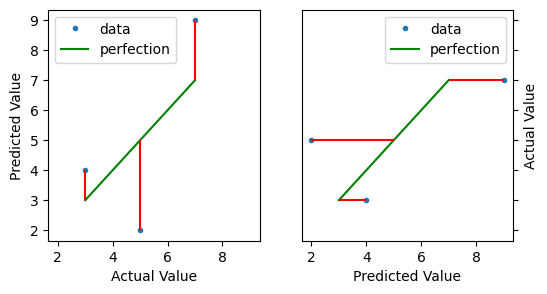

In [27]:
def regression_errors(figsize,predicted,actual,errors='all'):
    fig,axes  = plt.subplots(1,2,figsize=figsize, sharex = True, sharey = True)
    df = pd.DataFrame({'actual':actual,'predicted':predicted})
    for ax,(x,y ) in zip(axes,it.permutations(['actual','predicted'])):
        #plot the data as '.'
        ax.plot(df[x],df[y],'.',label='data')
        #plot the line as correct predictions
        ax.plot(df['actual'],df['actual'],'g-',label='perfection')
        ax.legend()

        ax.set_xlabel('{} Value'.format(x.capitalize()))
        ax.set_ylabel('{} Value'.format(y.capitalize()))
    axes[1].yaxis.tick_right()
    axes[1].yaxis.set_label_position("right")

    if errors == 'all':
        errors = range(len(df))
    if errors:
        acts = df.actual.iloc[errors]
        preds = df.predicted.iloc[errors]
        axes[0].vlines(acts,preds,acts,'r')
        axes[1].hlines(acts,preds,acts,'r')

regression_errors((6,3),ape_df.predicted,ape_df.actual)
        

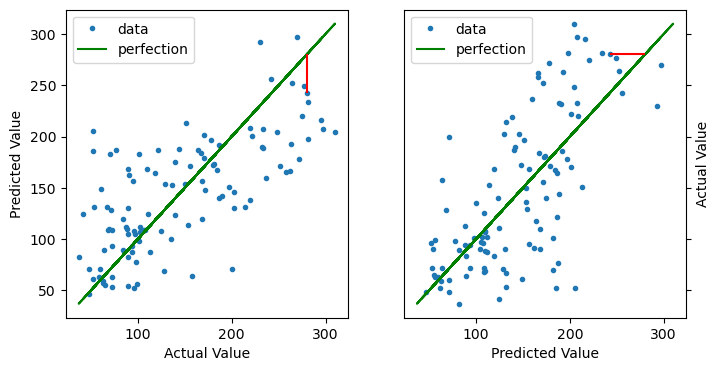

In [31]:
lr = linear_model.LinearRegression()
preds = (lr.fit(diabetes_train_ftrs,diabetes_train_tgt)).predict(diabetes_test_ftrs)
regression_errors((8,4),preds,diabetes_test_tgt,errors=[-20])